# Your own CDaRR stack, measured

The separation-manager pages write one component at a time and look at a single encounter. This
notebook assembles all three — a conflict **detector**, a **resolver** and a **recovery criterion**,
none of them from the library — into one stack, and measures it against the library's own
`StateBased` + `MVP` + `FTR` over 500 encounters per condition.

The point is not that the hand-written stack is good. It is that putting it on the same axes as the
reference costs nothing but a second `Methods` bundle: the encounters, the seeds, the noise draws
and the two reported metrics are identical, so the comparison differs only in the stack.

In [1]:
%matplotlib inline
import dataclasses
from collections.abc import Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    FTR,
    MC,
    MVP,
    Fixed,
    GnssNavigation,
    M600,
    Methods,
    StateBased,
    Sweep,
    geo,
    run_experiment,
)
from opencdarr.cd.base import ConflictDetector
from opencdarr.config import load_config
from opencdarr.cr.base import ConflictResolver
from opencdarr.crr.base import RecoveryCriterion
from opencdarr.kinematics import MotionCommand
from opencdarr.relative import relative_enu, velocity_enu
from opencdarr.state import AircraftState

BLUE, ORANGE = "#1f77b4", "#ff7f0e"

ANGLES = [2.0, 5.0, 10.0, 30.0]
NOISE = [10.0, 30.0]
SPEED, TLOS, RPZ, SEED = 10.0, 180.0, 50.0, 0

base = dataclasses.replace(load_config("../../configs/pairwise.yaml"), n_encounters=500)

SITE_IMG = Path.home() / "Projects/opencdarr.github.io/docs/assets/img"


def publish(fig, name: str) -> None:
    if SITE_IMG.is_dir():
        fig.savefig(SITE_IMG / f"{name}.png", dpi=130)

## The three components

Copied unchanged from the separation-manager pages. Each is one subclass with one method.

In [2]:
class ProximityDetect(ConflictDetector):
    # Flag a conflict when the intruder is currently within `trigger` metres. Reactive, not
    # predictive: it never looks ahead, so it wakes the resolver late.

    cache_id = "proximity-detect/v1"

    def __init__(self, trigger: float = 100.0) -> None:
        self.trigger = trigger

    def detect(self, own: AircraftState, intr: AircraftState,
               rpz: float, t_lookahead: float) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist <= self.trigger


class CloseRangeAvoid(ConflictResolver):
    # Hold course until an intruder is within `trigger` metres, then turn 90 deg right.

    cache_id = "close-range-avoid/v1"

    def __init__(self, trigger: float = 70.0) -> None:
        self.trigger = trigger

    def resolve(self, own: AircraftState, intruders: Sequence[AircraftState],
                rpz: float, preferred: tuple[float, float] | None = None) -> MotionCommand:
        v_east, v_north = velocity_enu(own)
        nearest = min((relative_enu(own, i).dist for i in intruders), default=float("inf"))
        if nearest <= self.trigger:
            return MotionCommand(target_velocity=(v_north, -v_east))   # 90 deg right
        return MotionCommand(target_velocity=(v_east, v_north))        # else: unchanged


class RangeClear(RecoveryCriterion):
    # Resume the mission once the intruder is at least `resume_dist` metres away.

    cache_id = "range-clear/v1"

    def __init__(self, resume_dist: float = 120.0) -> None:
        self.resume_dist = resume_dist

    def should_resume(self, own: AircraftState, intr: AircraftState, rpz: float) -> bool:
        _, dist = geo.qdrdist(own.lat, own.lon, intr.lat, intr.lon)
        return dist >= self.resume_dist


STACKS = {
    "reference": Methods(detector=StateBased(), resolver=MVP(1.05), recovery=FTR(),
                         navigation=GnssNavigation(), perf=M600),
    "mine": Methods(detector=ProximityDetect(100.0), resolver=CloseRangeAvoid(70.0),
                    recovery=RangeClear(120.0),
                    navigation=GnssNavigation(), perf=M600),
}

Each carries a `cache_id`. `cache=True` has to key every component distinctly, and by default
`identity()` does that by hashing the class's own source — which works, but is less stable for a
class defined in a notebook than for one in a file. Declaring the id means you own the promise of
bumping it when the logic changes.

## Two declarations, not one axis

A `Sweep` varies **one** parameter. A stack is three, so `detector=Sweep([...])`,
`resolver=Sweep([...])`, `recovery=Sweep([...])` would give the 2 × 2 × 2 cross-product — eight
mixed stacks, most of them meaningless.

Stack-against-stack is two declarations that differ only in their `Methods` bundle. Everything else
— the seed, the base config, the swept geometry — is identical, so **both stacks fly the same 500
encounters at each condition**, from the same seeds, with the same noise draws. That is what makes
the difference attributable to the stack.

In [3]:
declared = {"dpsi": Sweep(ANGLES), "pos_ci95": Sweep(NOISE),
            "vel_ci95": Fixed(1.0), "dcpa": Fixed(0.0),
            "tlos": Fixed(TLOS), "speed": Fixed(SPEED)}

rows = []
for name, methods in STACKS.items():
    result = run_experiment(declared, methods=methods, backend=MC(n_encounters=500),
                            base_config=base, seed=SEED, cache=True, n_jobs=4)
    rows += [{"stack": name, **r} for r in result.records()]

frame = pd.DataFrame(rows)
frame[["stack", "dpsi", "pos_ci95", "p_los", "p_los_lo", "p_los_hi",
       "median_min_sep", "n_los", "detection_rate"]].round(4)

,stack,dpsi,pos_ci95,p_los,p_los_lo,p_los_hi,median_min_sep,n_los,detection_rate
0,reference,2.0,10.0,0.000,0.0000,0.0076,71.9545,0,0.820
1,reference,2.0,30.0,0.002,0.0004,0.0112,78.2411,1,0.944
2,reference,5.0,10.0,0.000,0.0000,0.0076,74.5494,0,0.866
3,reference,5.0,30.0,0.002,0.0004,0.0112,79.8695,1,0.950
4,reference,10.0,10.0,0.000,0.0000,0.0076,78.1163,0,0.842
5,reference,10.0,30.0,0.000,0.0000,0.0076,77.6626,0,0.970
6,reference,30.0,10.0,0.000,0.0000,0.0076,76.7005,0,0.850
7,reference,30.0,30.0,0.006,0.0020,0.0175,73.5386,3,0.968
8,mine,2.0,10.0,0.106,0.0820,0.1361,62.9183,53,0.992
9,mine,2.0,30.0,0.288,0.2500,0.3292,58.1417,144,1.000


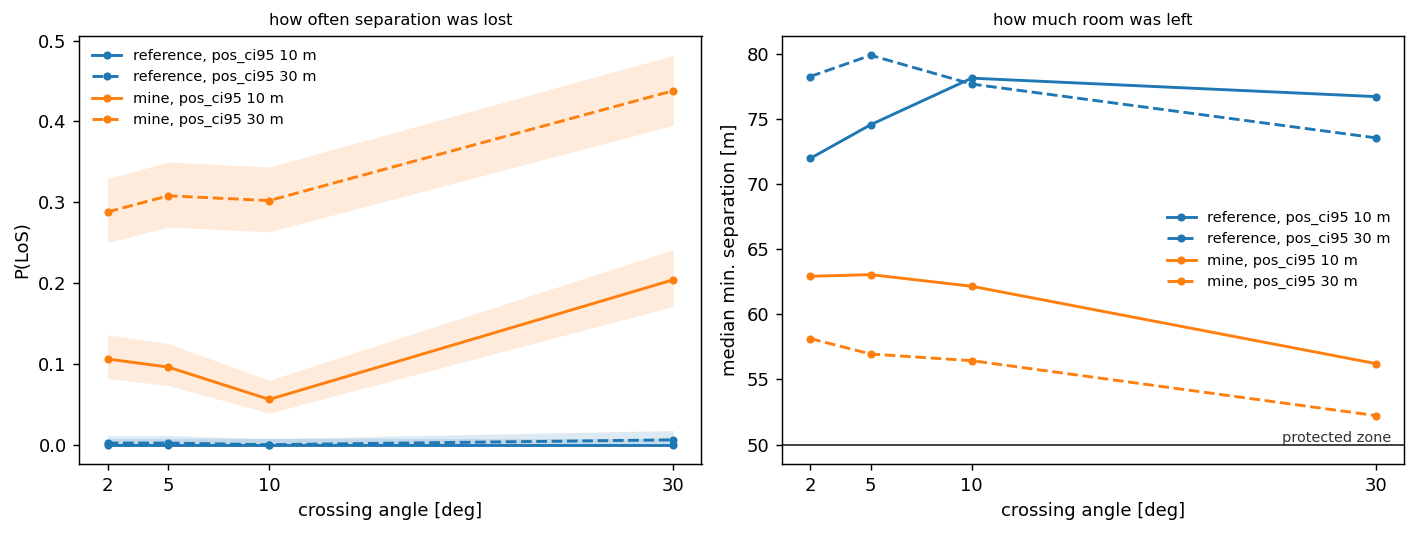

In [4]:
fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(11.0, 4.2))

for name, colour in (("reference", BLUE), ("mine", ORANGE)):
    for pos, style in zip(NOISE, ("-", "--")):
        g = sorted((r for r in rows if r["stack"] == name and r["pos_ci95"] == pos),
                   key=lambda r: r["dpsi"])
        xs = [r["dpsi"] for r in g]
        ax_p.plot(xs, [r["p_los"] for r in g], style, marker="o", ms=3.5, lw=1.6, color=colour,
                  label=f"{name}, pos_ci95 {pos:.0f} m")
        ax_p.fill_between(xs, [r["p_los_lo"] for r in g], [r["p_los_hi"] for r in g],
                          alpha=0.15, color=colour, lw=0)
        ax_m.plot(xs, [r["median_min_sep"] for r in g], style, marker="o", ms=3.5, lw=1.6,
                  color=colour, label=f"{name}, pos_ci95 {pos:.0f} m")

ax_m.axhline(RPZ, color="0.2", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.2")
for ax, ylab, title in ((ax_p, "P(LoS)", "how often separation was lost"),
                        (ax_m, "median min. separation [m]", "how much room was left")):
    ax.set_xlabel("crossing angle [deg]")
    ax.set_ylabel(ylab)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(ANGLES)
    ax.legend(frameon=False, fontsize=8, loc="best")
fig.tight_layout()
publish(fig, "byo-cdarr-response")

The reference stack clears essentially everything: **0.000 to 0.006** across the whole grid, with
zero losses in 500 encounters in five of the eight cells. The hand-written stack loses separation in
**5.6% to 43.8%** of them.

That gap is not the interesting part — a fifteen-line rule losing to MVP is not news. The **shape**
is. The reference is flat and low across the angle axis. Ours gets *worse* as the crossing widens:
0.056 at 10° against **0.204 at 30°** with a 10 m fix. Wider crossings are the easy end for every
resolver in the library, and this stack goes backwards there.

The reason is visible in the components. Both of the thresholds are **distances** — the detector
fires inside 100 m, the resolver turns inside 70 m — and a distance is not a warning time:

| crossing | closing speed | time from the 100 m trigger | time from the 70 m turn |
|---|---|---|---|
| 2° | 0.35 m/s | 287 s | 200 s |
| 5° | 0.87 m/s | 115 s | 80 s |
| 10° | 1.74 m/s | 57 s | 40 s |
| 30° | 5.18 m/s | **19 s** | **13 s** |

Thirteen seconds is not long enough to turn 90° and translate clear at 10 m/s. `StateBased` avoids
this by predicting the closest point of approach and firing on `t_lookahead`, which is a time; ours
never looks ahead at all.

**It is also far more sensitive to the position fix.** Tripling `pos_ci95` moves the reference
barely at all, while ours goes 0.106 → 0.288 at 2° and 0.056 → 0.302 at 10°. A rule that switches
on a threshold fires at the wrong moment when the distance it reads is wrong by tens of metres; a
rule that steers along a gradient degrades more gracefully.

**The medians say where each one lives.** Ours sits between 52 m and 63 m — on top of a 50 m
protected zone, which is what a fixed trigger produces: start avoiding at a fixed range, finish at a
fixed range. The reference holds 72–80 m and, notably, holds it *flat* across the angle axis, which
is FTR's signature — it reverts as soon as reverting is safe rather than over-holding, so it does
not bank extra separation at wide angles the way `PastCPA` does.

One honest limit on all of this: three components changed at once, so nothing here attributes the
failure to any single one. The last section says how to find out.

## Where it goes next

The comparison above is deliberately coarse — one stack against another, so a difference is
attributable to *the stack* and nothing finer. Three ways to sharpen it:

- **Find which component costs what.** Declare `detector`, `resolver` and `recovery` as three
  separate axes and the cross-product gives all eight combinations, including the hybrids. That
  isolates the contribution of each swap, at the price of eight times the runs and a table that
  invites reading interactions 500 encounters may not resolve.
- **Sweep your own parameter.** `Sweep([50.0, 70.0, 100.0], build=lambda t: CloseRangeAvoid(t),
  name="trigger")` puts your trigger distance in the table as a plottable numeric column, which is
  the fastest way to find out whether a threshold is the problem or the rule is.
- **Look at the record, not just the rate.** `sweep.cell(...).min_seps` holds every encounter's
  achieved separation, so `P(min_sep < 25)` or a quantile is a read rather than another run — see
  the [Monte Carlo estimator](https://opencdarr.github.io/estimators/monte-carlo/).